Original shape: (1505, 82)
Non-numeric columns: ['lead_vill', 'village', 'community_type', 'cocoa_variety_1', 'cocoa_variety_2', 'cocoa_variety_3', 'cocoa_variety_4', 'noncocoa_whyno_1', 'noncocoa_whyno_2', 'noncocoa_whyno_3', 'noncocoa_whyno_4', 'noncocoa_whyno_5']
Columns with highest missing values:
cocoa_variety_5    1499
hhgroup_f17        1488
hhgroup_m17        1488
hhgroup_f18        1488
hhgroup_f18.1      1488
hhgroup_f17.1      1488
hhgroup_m17.1      1488
hhgroup_m18.1      1488
hhgroup_m18        1488
cocoa_variety_4    1477
dtype: int64
Total missing values: 39478
Shape after filtering rows with target not null: (1442, 82)
Shape after dropping specified columns: (1442, 76)
Training data shape: (1153, 75)
Testing data shape: (289, 75)
Train R²: 0.9187
Test R²: -0.0027


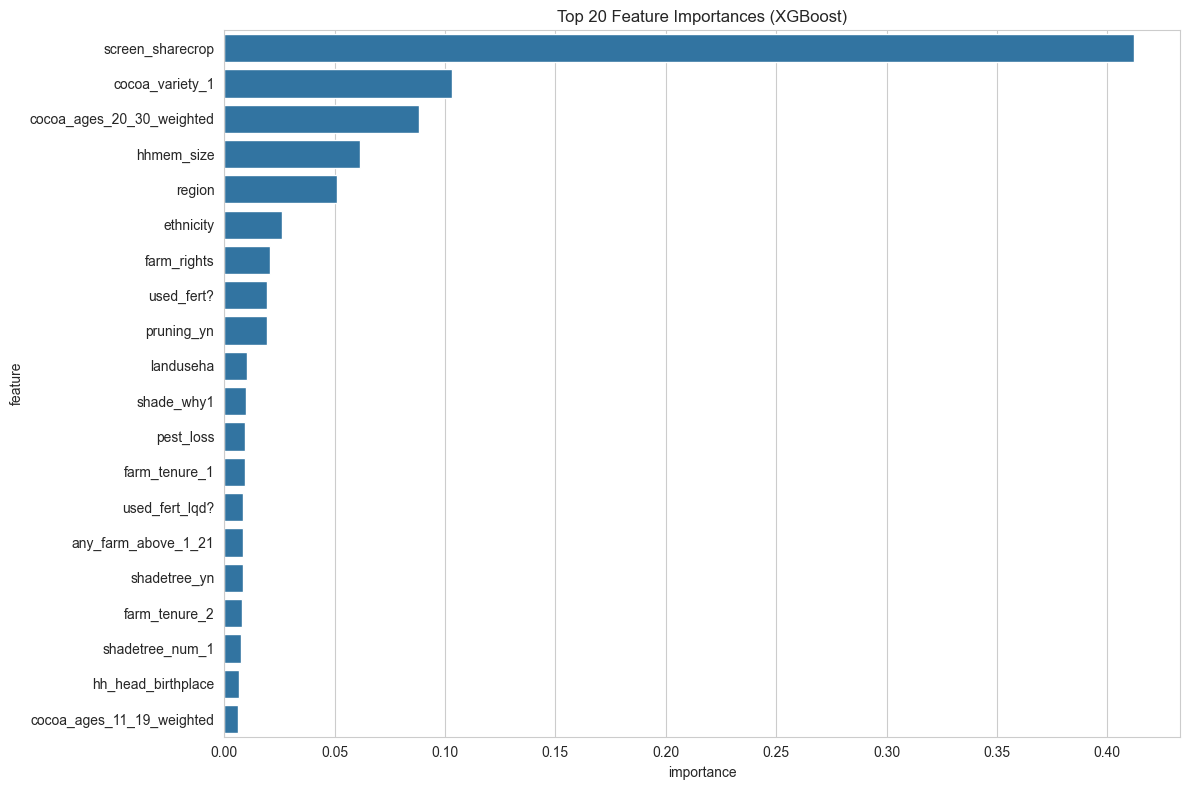

In [131]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("C:/Users/Mohamad/Documents/GitHub/GAFL_RESTORE_MKM/Data/processed/CDI_HOUSEHOLD_UNEDITTED.csv")
print(f"Original shape: {df.shape}")

# Identify non-numeric columns
non_numeric_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Non-numeric columns: {non_numeric_cols}")

# Check missing values before any processing
missing_values = df.isnull().sum()
print("Columns with highest missing values:")
print(missing_values.sort_values(ascending=False).head(10))
print(f"Total missing values: {df.isnull().sum().sum()}")

# Define target variable
target = 'cocoa_yield_ha'
# Define columns to drop
# These columns are not needed for the model and should be removed
drop_cols = ["cocoa_produce_kg", "cocoa_produce_main_kg", "cocoa_produce_light_kg", "village", "cocoa_sell_kg", "cocoa_price_kg"]

# Check if target exists in the dataframe
if target not in df.columns:
    raise ValueError(f"Target variable '{target}' not found in data.")

# Keep only rows where target variable is not null
df = df[~df[target].isnull()]
print(f"Shape after filtering rows with target not null: {df.shape}")

# Handle missing values in other columns (imputation)
# For numeric columns, fill with median
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# For categorical columns (if any), fill with most frequent value
for col in non_numeric_cols:
    if col in df.columns:  # Check if column exists
        df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "Unknown")

# Now drop the specified columns if they exist
cols_to_drop = [col for col in drop_cols if col in df.columns]
df = df.drop(columns=cols_to_drop)
print(f"Shape after dropping specified columns: {df.shape}")

# Handle categorical features for XGBoost
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Define features and target for model
X = df.drop(columns=[target])
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Train XGBoost model
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    enable_categorical=True,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")

# Feature importance
importances = model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'feature': features, 'importance': importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(20), x='importance', y='feature')
plt.title("Top 20 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()

In [132]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_importances = rf.feature_importances_
rf_df = pd.DataFrame({'feature': X.columns, 'importance': rf_importances})
rf_df = rf_df.sort_values(by='importance', ascending=False)

print("\nTop 10 Random Forest Features:")
print(rf_df.head(10))



Top 10 Random Forest Features:
                      feature  importance
72  cocoa_ages_20_30_weighted    0.084633
11                   district    0.082779
23            cocoa_variety_1    0.077288
1                   landuseha    0.071303
57                farm_rights    0.057325
12                       vill    0.053000
66                hh_head_age    0.047938
48            shadetree_num_1    0.042711
9            screen_sharecrop    0.039607
33              farm_tenure_1    0.033883


C:\Users\Mohamad\AppData\Local\Temp\ipykernel_32276\3229474229.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


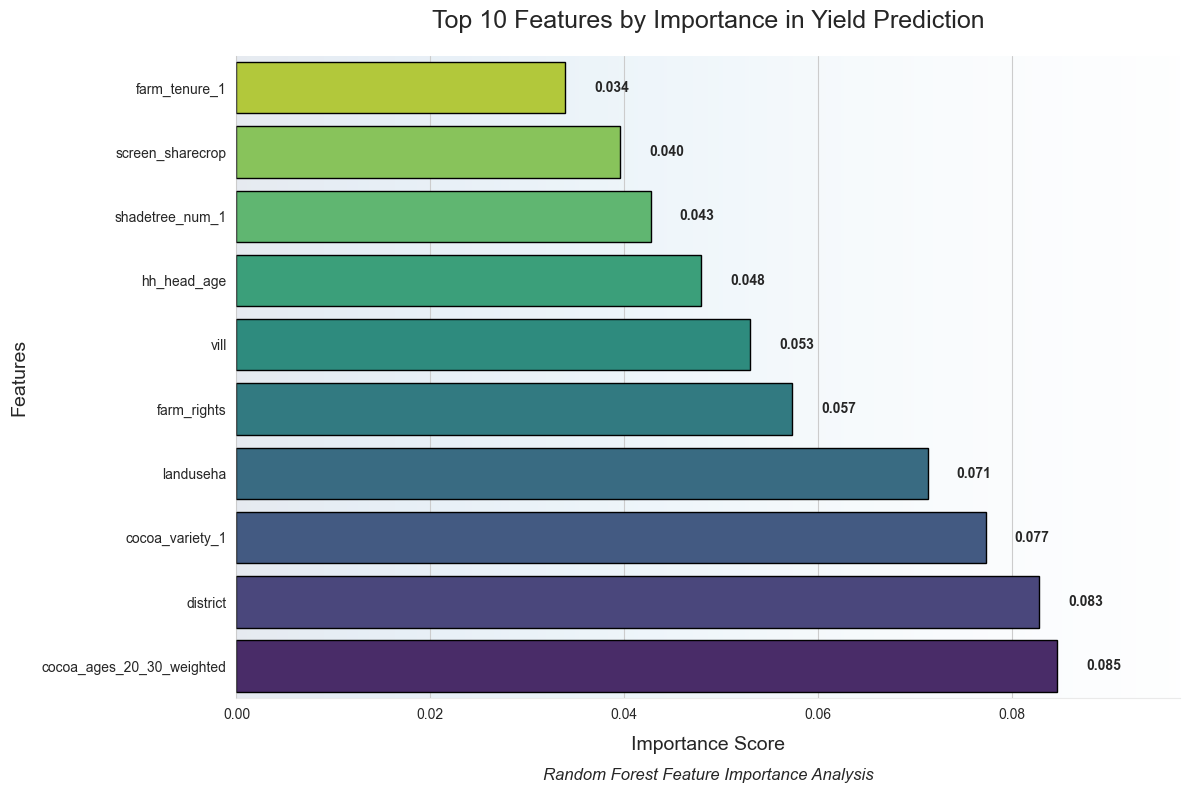

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style and color palette
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

# Create a copy of the dataframe to avoid modifying the original
plot_df = rf_df.head(10).copy()  # Top 10 features

# Create the bar plot with a modern color palette
ax = sns.barplot(
    x='importance', 
    y='feature', 
    data=plot_df,
    palette='viridis',
    edgecolor='black',
    linewidth=1
)

# Add data labels to the bars
for i, v in enumerate(plot_df['importance']):
    ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontweight='bold')

# Add a subtle gradient background
gradient = np.linspace(0, 1, 256).reshape(1, -1)
plt.imshow(gradient, aspect='auto', extent=[0, plot_df['importance'].max()*1.15, -0.5, len(plot_df)-0.5], 
           alpha=0.1, cmap='Blues_r')

# Customize the plot
plt.title('Top 10 Features by Importance in Yield Prediction', fontsize=18, pad=20)
plt.xlabel('Importance Score', fontsize=14, labelpad=10)
plt.ylabel('Features', fontsize=14, labelpad=10)

# Add annotations
plt.annotate('Random Forest Feature Importance Analysis', 
             xy=(0.5, -0.12), 
             xycoords='axes fraction', 
             ha='center', 
             va='center',
             fontsize=12,
             fontstyle='italic')

# Adjust layout
plt.tight_layout()
plt.xlim(0, plot_df['importance'].max() * 1.15)

# Add a subtle border
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_alpha(0.4)
plt.gca().spines['left'].set_alpha(0.4)

# Save the figure (optional)
plt.savefig('rf_feature_importance.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

In [134]:
print(f"Original shape: {df.shape}")
df = df.dropna()
print(f"After dropping rows with NaN values: {df.shape}")



Original shape: (1442, 76)
After dropping rows with NaN values: (1442, 76)



Elastic Net Results:
Test R²: -0.0021
Test RMSE: 9395.14

Top 20 Features with Directionality:
                      feature  coefficient  abs_coefficient
57                farm_rights   -29.603300        29.603300
1                   landuseha   -22.289935        22.289935
69    cocoa_ages_0_5_weighted   -16.146898        16.146898
68         hh_head_birthplace   -16.034706        16.034706
9            screen_sharecrop    15.690654        15.690654
33              farm_tenure_1    14.861171        14.861171
22                 econstatus    13.778559        13.778559
66                hh_head_age   -12.452621        12.452621
12                       vill   -11.201093        11.201093
72  cocoa_ages_20_30_weighted     9.944493         9.944493
21                    femhead    -9.517473         9.517473
73     cocoa_ages_31_weighted    -8.138586         8.138586
60                    replant    -6.962466         6.962466
49                 used_fert?     6.380416         6.380416
4   

C:\Users\Mohamad\AppData\Local\Temp\ipykernel_32276\3030905838.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


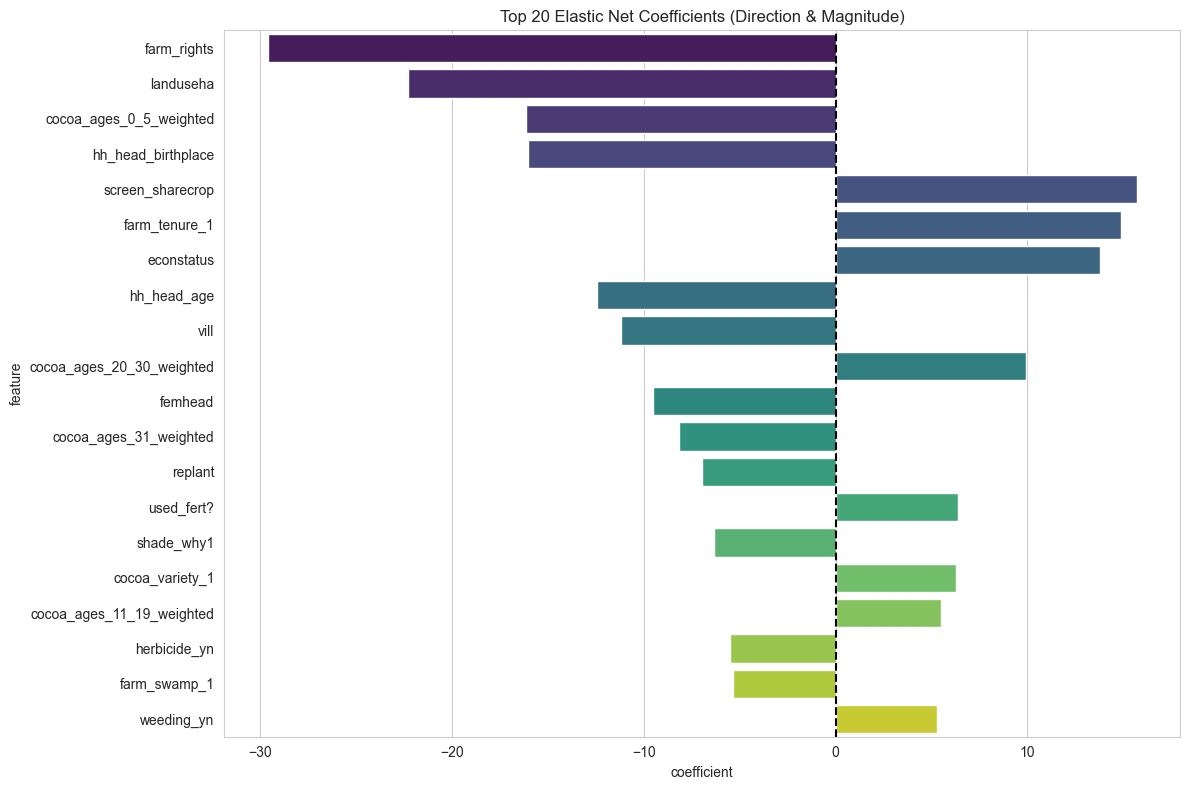


Interpretation Guide:
- Positive coefficients: Increase in feature value PREDICTS HIGHER cocoa production
- Negative coefficients: Increase in feature value PREDICTS LOWER cocoa production
- Coefficient magnitude shows relative importance


In [135]:
# Add these imports at the top
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# [After your existing XGBoost and Random Forest code] ##########################

# Add Elastic Net implementation
def elastic_net_analysis(X_train, X_test, y_train, y_test):
    # Create pipeline with standardization and Elastic Net
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('enet', ElasticNetCV(
            l1_ratio=[.1, .5, .7, .9, .95],  # Mix of L1/L2 regularization
            cv=5,
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    # Fit model
    pipeline.fit(X_train, y_train)
    
    # Get coefficients
    coefs = pd.DataFrame({
        'feature': X_train.columns,
        'coefficient': pipeline.named_steps['enet'].coef_,
        'abs_coefficient': np.abs(pipeline.named_steps['enet'].coef_)
    }).sort_values('abs_coefficient', ascending=False)
    
    # Evaluate
    y_pred = pipeline.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"\nElastic Net Results:")
    print(f"Test R²: {test_r2:.4f}")
    print(f"Test RMSE: {test_rmse:.2f}")
    print("\nTop 20 Features with Directionality:")
    print(coefs.head(20))
    
    # Plot coefficients
    plt.figure(figsize=(12, 8))
    sns.barplot(
        x='coefficient', 
        y='feature', 
        data=coefs.head(20),
        palette='viridis'
    )
    plt.title("Top 20 Elastic Net Coefficients (Direction & Magnitude)")
    plt.axvline(0, color='k', linestyle='--')
    plt.tight_layout()
    plt.show()
    
    return coefs

# Run the analysis
en_coefs = elastic_net_analysis(X_train, X_test, y_train, y_test)

# Interpretation helper
print("\nInterpretation Guide:")
print("- Positive coefficients: Increase in feature value PREDICTS HIGHER cocoa production")
print("- Negative coefficients: Increase in feature value PREDICTS LOWER cocoa production")
print("- Coefficient magnitude shows relative importance")

In [136]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# 1. ------------------------------------------------------------------
#    Load data ---------------------------------------------------------
df = pd.read_csv(
    r"C:/Users/Mohamad/Documents/GitHub/GAFL_RESTORE_MKM/Data/processed/CDI_HOUSEHOLD_UNEDITTED.csv"
)

# 2. ------------------------------------------------------------------
#    Make column names safe for formula strings -----------------------
#    patsy (the formula engine statsmodels uses) rejects ? / spaces / % etc.
#    We'll keep a copy of the original names if you ever need them.
bad_chars = {"?": "_q", " ": "_", "-": "_", "/": "_", "%": "pct"}
def make_safe(col):
    for k, v in bad_chars.items():
        col = col.replace(k, v)
    return col
df = df.rename(columns={c: make_safe(c) for c in df.columns})

# 3. ------------------------------------------------------------------
#    Define outcome, predictors, cluster var --------------------------
outcome     = "cocoa_yield_ha"

predictors  = [
    "econstatus",      # treat econ status as categorical
    "C(yrs_grow)",
    "femhead",            # already 0/1 in the raw file
    "herbicide_yn",
    "pesticide_yn",
    "shadetree_yn",
    "used_fert_q",
    "used_fert_lqd_q",
    "fungicide_yn",
    "weeding_yn", 
    "pruning_yn",
    "disease_loss",
    "pest_loss",
    "replant",
    "farm_rights",
    "cocoa_ages_0_5_weighted",
    "cocoa_ages_6_10_weighted",
    "cocoa_ages_11_19_weighted",
    "cocoa_ages_20_30_weighted",
    "cocoa_ages_31_weighted",


    # ---- optional barrier variables you might add later -------------
    # "pest_loss", "disease_loss", "replant",
    # "used_fert_q",     # note the '?' is now '_q' after renaming
]

cluster_var = "vill"       # cluster at village level

formula = outcome + " ~ " + " + ".join(predictors)

# 4. ------------------------------------------------------------------
#    Drop rows with missing values in *any* variable used -------------
vars_needed = (
    [outcome, cluster_var] +
    [p.lstrip("C(").rstrip(")") for p in predictors]   # strip C() wrappers
)
df_clean = df.dropna(subset=vars_needed)

# 5. ------------------------------------------------------------------
#    Fit the model with cluster‑robust SEs ----------------------------
model = smf.ols(formula, data=df_clean)
fit   = model.fit(cov_type="cluster",
                  cov_kwds={"groups": df_clean[cluster_var]})

print(fit.summary())


                            OLS Regression Results                            
Dep. Variable:         cocoa_yield_ha   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                     2.622
Date:                Mon, 12 May 2025   Prob (F-statistic):           0.000454
Time:                        04:32:44   Log-Likelihood:                -14078.
No. Observations:                1442   AIC:                         2.821e+04
Df Residuals:                    1417   BIC:                         2.834e+04
Df Model:                          24                                         
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

Dropped 32 farms (2.22%) as extreme outliers


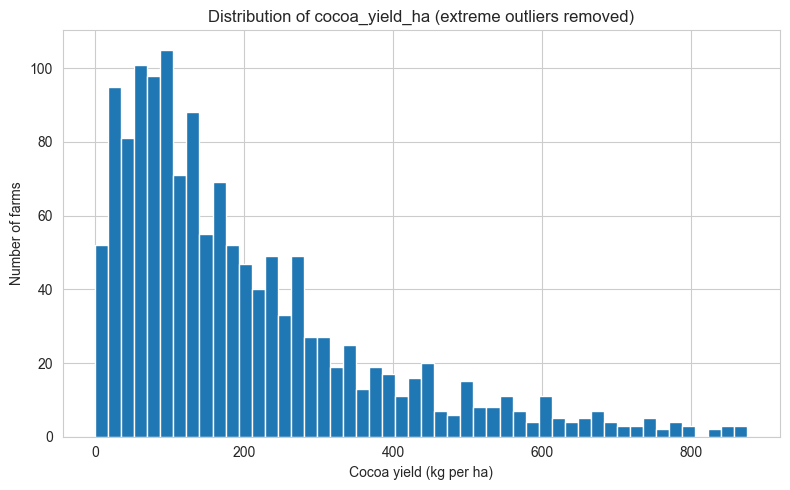

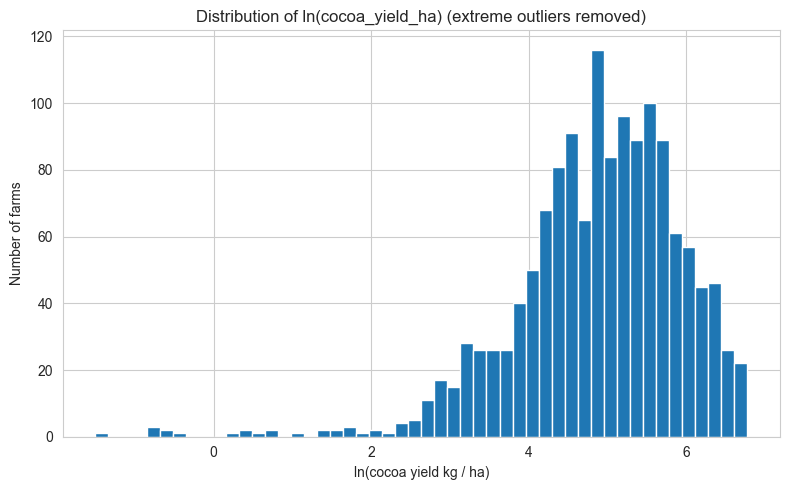

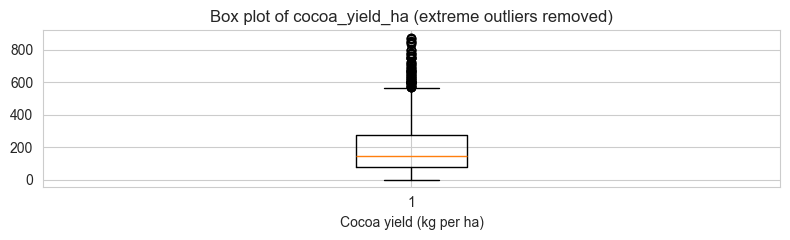

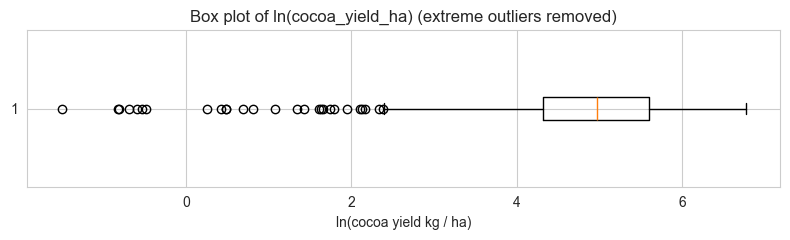

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1.  Keep rows with a positive yield (already in kg / ha)
# -------------------------------------------------------------
df = df[df["cocoa_yield_ha"] > 0].copy()

# -------------------------------------------------------------
# 2.  Identify “extreme” outliers with the 3×IQR rule
#     (milder outliers inside 1.5×IQR stay in the data)
# -------------------------------------------------------------
q1 = df["cocoa_yield_ha"].quantile(0.25)
q3 = df["cocoa_yield_ha"].quantile(0.75)
iqr = q3 - q1

lower_bound = max(0, q1 - 3 * iqr)          # yield can’t be <0 anyway
upper_bound = q3 + 3 * iqr

df_trim = df[(df["cocoa_yield_ha"] >= lower_bound) &
             (df["cocoa_yield_ha"] <= upper_bound)].copy()

print(f"Dropped {len(df) - len(df_trim)} farms "
      f"({(len(df) - len(df_trim)) / len(df):.2%}) as extreme outliers")

# -------------------------------------------------------------
# 3‑A.  Histogram on the raw scale (trimmed)
# -------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(df_trim["cocoa_yield_ha"], bins=50)
plt.xlabel("Cocoa yield (kg per ha)")
plt.ylabel("Number of farms")
plt.title("Distribution of cocoa_yield_ha (extreme outliers removed)")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 3‑B.  Histogram on the log scale (trimmed)
# -------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(np.log(df_trim["cocoa_yield_ha"]), bins=50)
plt.xlabel("ln(cocoa yield kg / ha)")
plt.ylabel("Number of farms")
plt.title("Distribution of ln(cocoa_yield_ha) (extreme outliers removed)")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 3‑C.  Box‑plots (raw and log scales, trimmed)
# -------------------------------------------------------------
plt.figure(figsize=(8, 2.5))
plt.boxplot(df_trim["cocoa_yield_ha"], vert=True, showfliers=True)
plt.xlabel("Cocoa yield (kg per ha)")
plt.title("Box plot of cocoa_yield_ha (extreme outliers removed)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 2.5))
plt.boxplot(np.log(df_trim["cocoa_yield_ha"]), vert=False, showfliers=True)
plt.xlabel("ln(cocoa yield kg / ha)")
plt.title("Box plot of ln(cocoa_yield_ha) (extreme outliers removed)")
plt.tight_layout()
plt.show()


In [138]:
import pandas as pd, numpy as np, re, statsmodels.formula.api as smf

# ------------------------------------------------------------------
# 1.  Load & make names formula‑safe  (same as before)
# ------------------------------------------------------------------
df = pd.read_csv(
    r"C:/Users/Mohamad/Documents/GitHub/GAFL_RESTORE_MKM/Data/processed/CDI_HOUSEHOLD_UNEDITTED.csv"
)


bad = {'?':'_q',' ':'_', '-':'_', '/':'_', '%':'pct'}
df.rename(columns={c: re.sub('[^0-9A-Za-z_]', '',
                ''.join(bad.get(ch,ch) for ch in c)) for c in df.columns},
          inplace=True)

# ------------------------------------------------------------------
# 2.  Yield, trimming, log
# ------------------------------------------------------------------
df = df[(df.landuseha>0)&(df.cocoa_produce_kg>0)].copy()
df["yield_ha"] = df.cocoa_produce_kg / df.landuseha

q1,q3 = df.yield_ha.quantile([.25,.75]); iqr=q3-q1
df = df[(df.yield_ha<=q3+3*iqr)&(df.yield_ha>=max(0,q1-3*iqr))].copy()
df["ln_yield"] = np.log(df.yield_ha)

# ------------------------------------------------------------------
# 3.  Re‑code extra predictors
# ------------------------------------------------------------------
df["any_chemical"] = (df[["herbicide_yn","pesticide_yn","fungicide_yn"]]==1
                      ).any(axis=1).astype(int)

df["young_share"] = df.cocoa_ages_0_5_weighted.fillna(0) \
                  + df.cocoa_ages_6_10_weighted.fillna(0)
df["prime_share"] = df.cocoa_ages_11_19_weighted.fillna(0) \
                  + df.cocoa_ages_20_30_weighted.fillna(0)
# cocoa_ages_31_weighted is the implicit base

# ------------------------------------------------------------------
# 4.  Define formula (yrs_grow categorical, farm_rights categorical)
# ------------------------------------------------------------------
formula = """
ln_yield
  ~ C(yrs_grow)
  + femhead
  + any_chemical + weeding_yn + pruning_yn
  + used_fert_q + used_fert_lqd_q
  + pest_loss + disease_loss + replant
  + C(farm_rights)
  + young_share + prime_share
  + C(econstatus)
"""

# ------------------------------------------------------------------
# 5.  Pre‑drop only variables that REALLY must exist
#     (no C() wrappers here)
# ------------------------------------------------------------------
must_have = [
    "ln_yield", "yrs_grow", "femhead", "any_chemical", "weeding_yn",
    "pruning_yn", "used_fert_q", "used_fert_lqd_q",
    "pest_loss", "disease_loss", "replant", "farm_rights",
    "young_share", "prime_share", "econstatus", "vill"
]
df_reg = df.dropna(subset=must_have).copy()

# ------------------------------------------------------------------
# 6.  Fit OLS with village‑level clustered SEs
#     statsmodels will automatically drop any *additional* NAs
# ------------------------------------------------------------------
fit = smf.ols(formula, data=df_reg, missing='drop').fit(
        cov_type='cluster',
        cov_kwds={'groups': df_reg['vill']}
)

print(fit.summary())


                            OLS Regression Results                            
Dep. Variable:               ln_yield   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     8.185
Date:                Mon, 12 May 2025   Prob (F-statistic):           4.83e-15
Time:                        04:32:45   Log-Likelihood:                -2008.7
No. Observations:                1409   AIC:                             4071.
Df Residuals:                    1382   BIC:                             4213.
Df Model:                          26                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               3.3955    

Original shape: (1505, 82)
Non-numeric columns: ['lead_vill', 'village', 'community_type', 'cocoa_variety_1', 'cocoa_variety_2', 'cocoa_variety_3', 'cocoa_variety_4', 'noncocoa_whyno_1', 'noncocoa_whyno_2', 'noncocoa_whyno_3', 'noncocoa_whyno_4', 'noncocoa_whyno_5']
Columns with highest missing values:
cocoa_variety_5    1499
hhgroup_f17        1488
hhgroup_m17        1488
hhgroup_f18        1488
hhgroup_f18.1      1488
hhgroup_f17.1      1488
hhgroup_m17.1      1488
hhgroup_m18.1      1488
hhgroup_m18        1488
cocoa_variety_4    1477
dtype: int64
Total missing values: 39478
Shape after filtering rows with target not null: (1442, 82)
Shape after dropping specified columns: (1442, 76)
Training data shape: (1153, 75)
Testing data shape: (289, 75)
Train R²: 0.9187
Test R²: -0.0027


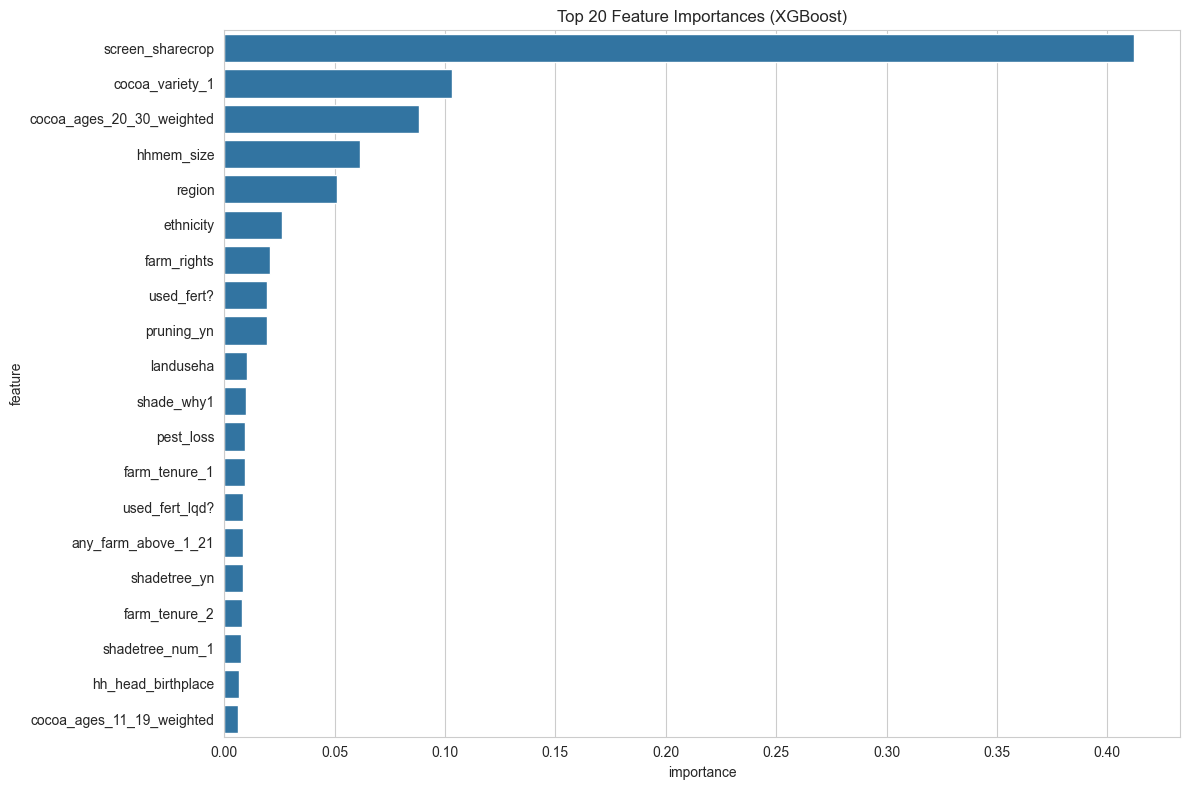

In [139]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("C:/Users/Mohamad/Documents/GitHub/GAFL_RESTORE_MKM/Data/processed/CDI_HOUSEHOLD_UNEDITTED.csv")
print(f"Original shape: {df.shape}")

# Identify non-numeric columns
non_numeric_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Non-numeric columns: {non_numeric_cols}")

# Check missing values before any processing
missing_values = df.isnull().sum()
print("Columns with highest missing values:")
print(missing_values.sort_values(ascending=False).head(10))
print(f"Total missing values: {df.isnull().sum().sum()}")

# Define target variable
target = 'cocoa_yield_ha'
# Define columns to drop
# These columns are not needed for the model and should be removed
drop_cols = ["cocoa_produce_kg", "cocoa_produce_main_kg", "cocoa_produce_light_kg", "village", "cocoa_sell_kg", "cocoa_price_kg"]

# Check if target exists in the dataframe
if target not in df.columns:
    raise ValueError(f"Target variable '{target}' not found in data.")

# Keep only rows where target variable is not null
df = df[~df[target].isnull()]
print(f"Shape after filtering rows with target not null: {df.shape}")

# Handle missing values in other columns (imputation)
# For numeric columns, fill with median
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# For categorical columns (if any), fill with most frequent value
for col in non_numeric_cols:
    if col in df.columns:  # Check if column exists
        df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "Unknown")

# Now drop the specified columns if they exist
cols_to_drop = [col for col in drop_cols if col in df.columns]
df = df.drop(columns=cols_to_drop)
print(f"Shape after dropping specified columns: {df.shape}")

# Handle categorical features for XGBoost
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Define features and target for model
X = df.drop(columns=[target])
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Train XGBoost model
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    enable_categorical=True,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")

# Feature importance
importances = model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'feature': features, 'importance': importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(20), x='importance', y='feature')
plt.title("Top 20 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()

In [140]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_importances = rf.feature_importances_
rf_df = pd.DataFrame({'feature': X.columns, 'importance': rf_importances})
rf_df = rf_df.sort_values(by='importance', ascending=False)

print("\nTop 10 Random Forest Features:")
print(rf_df.head(10))



Top 10 Random Forest Features:
                      feature  importance
72  cocoa_ages_20_30_weighted    0.084633
11                   district    0.082779
23            cocoa_variety_1    0.077288
1                   landuseha    0.071303
57                farm_rights    0.057325
12                       vill    0.053000
66                hh_head_age    0.047938
48            shadetree_num_1    0.042711
9            screen_sharecrop    0.039607
33              farm_tenure_1    0.033883


In [141]:
print(f"Original shape: {df.shape}")
df = df.dropna()
print(f"After dropping rows with NaN values: {df.shape}")



Original shape: (1442, 76)
After dropping rows with NaN values: (1442, 76)



Elastic Net Results:
Test R²: -0.0021
Test RMSE: 9395.14

Top 20 Features with Directionality:
                      feature  coefficient  abs_coefficient
57                farm_rights   -29.603300        29.603300
1                   landuseha   -22.289935        22.289935
69    cocoa_ages_0_5_weighted   -16.146898        16.146898
68         hh_head_birthplace   -16.034706        16.034706
9            screen_sharecrop    15.690654        15.690654
33              farm_tenure_1    14.861171        14.861171
22                 econstatus    13.778559        13.778559
66                hh_head_age   -12.452621        12.452621
12                       vill   -11.201093        11.201093
72  cocoa_ages_20_30_weighted     9.944493         9.944493
21                    femhead    -9.517473         9.517473
73     cocoa_ages_31_weighted    -8.138586         8.138586
60                    replant    -6.962466         6.962466
49                 used_fert?     6.380416         6.380416
4   

C:\Users\Mohamad\AppData\Local\Temp\ipykernel_32276\3030905838.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


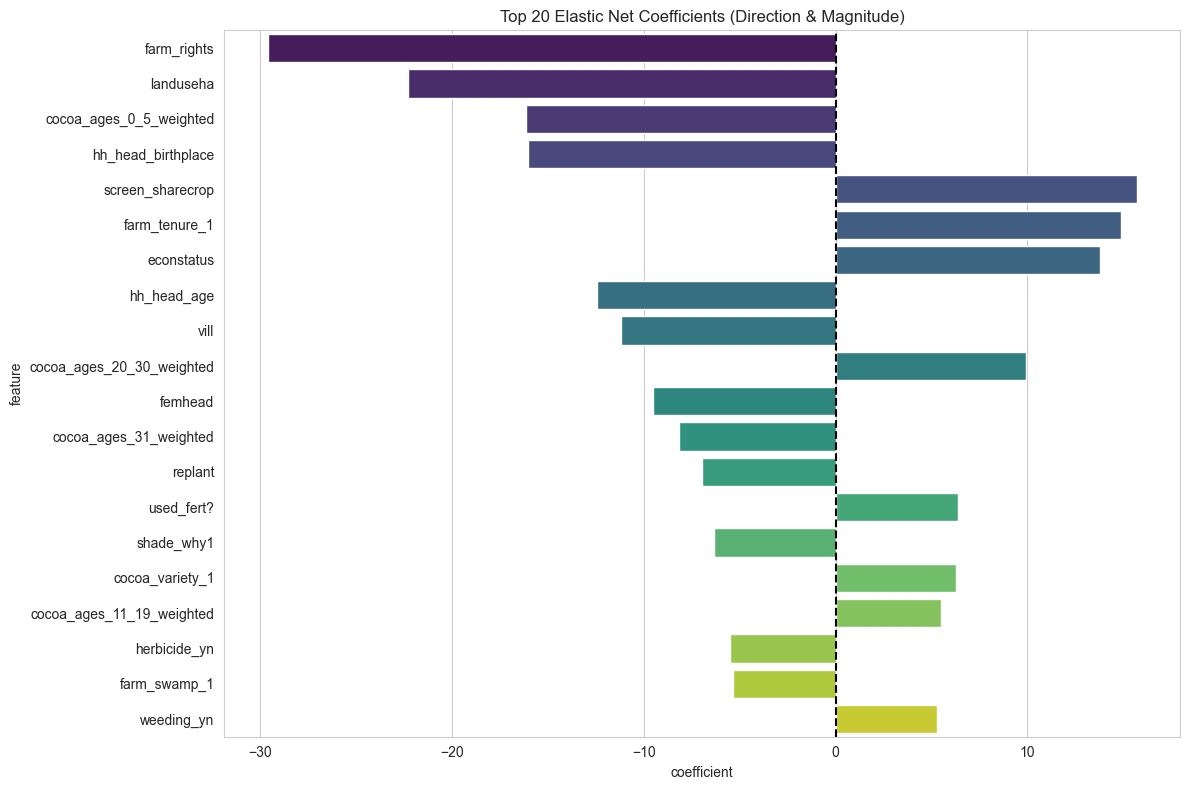


Interpretation Guide:
- Positive coefficients: Increase in feature value PREDICTS HIGHER cocoa production
- Negative coefficients: Increase in feature value PREDICTS LOWER cocoa production
- Coefficient magnitude shows relative importance


In [142]:
# Add these imports at the top
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# [After your existing XGBoost and Random Forest code] ##########################

# Add Elastic Net implementation
def elastic_net_analysis(X_train, X_test, y_train, y_test):
    # Create pipeline with standardization and Elastic Net
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('enet', ElasticNetCV(
            l1_ratio=[.1, .5, .7, .9, .95],  # Mix of L1/L2 regularization
            cv=5,
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    # Fit model
    pipeline.fit(X_train, y_train)
    
    # Get coefficients
    coefs = pd.DataFrame({
        'feature': X_train.columns,
        'coefficient': pipeline.named_steps['enet'].coef_,
        'abs_coefficient': np.abs(pipeline.named_steps['enet'].coef_)
    }).sort_values('abs_coefficient', ascending=False)
    
    # Evaluate
    y_pred = pipeline.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"\nElastic Net Results:")
    print(f"Test R²: {test_r2:.4f}")
    print(f"Test RMSE: {test_rmse:.2f}")
    print("\nTop 20 Features with Directionality:")
    print(coefs.head(20))
    
    # Plot coefficients
    plt.figure(figsize=(12, 8))
    sns.barplot(
        x='coefficient', 
        y='feature', 
        data=coefs.head(20),
        palette='viridis'
    )
    plt.title("Top 20 Elastic Net Coefficients (Direction & Magnitude)")
    plt.axvline(0, color='k', linestyle='--')
    plt.tight_layout()
    plt.show()
    
    return coefs

# Run the analysis
en_coefs = elastic_net_analysis(X_train, X_test, y_train, y_test)

# Interpretation helper
print("\nInterpretation Guide:")
print("- Positive coefficients: Increase in feature value PREDICTS HIGHER cocoa production")
print("- Negative coefficients: Increase in feature value PREDICTS LOWER cocoa production")
print("- Coefficient magnitude shows relative importance")

In [143]:
import pandas as pd, numpy as np, re, statsmodels.formula.api as smf

# ------------------------------------------------------------------
# 1.  Load & make names formula‑safe  (same as before)
# ------------------------------------------------------------------
df = pd.read_csv(
    r"C:/Users/Mohamad/Documents/GitHub/GAFL_RESTORE_MKM/Data/processed/CDI_HOUSEHOLD_UNEDITTED.csv"
)


bad = {'?':'_q',' ':'_', '-':'_', '/':'_', '%':'pct'}
df.rename(columns={c: re.sub('[^0-9A-Za-z_]', '',
                ''.join(bad.get(ch,ch) for ch in c)) for c in df.columns},
          inplace=True)

# ------------------------------------------------------------------
# 2.  Yield, trimming, log
# ------------------------------------------------------------------
df = df[(df.landuseha>0)&(df.cocoa_produce_kg>0)].copy()
df["yield_ha"] = df.cocoa_produce_kg / df.landuseha

q1,q3 = df.yield_ha.quantile([.25,.75]); iqr=q3-q1
df = df[(df.yield_ha<=q3+3*iqr)&(df.yield_ha>=max(0,q1-3*iqr))].copy()
df["ln_yield"] = np.log(df.yield_ha)

# ------------------------------------------------------------------
# 3.  Re‑code extra predictors
# ------------------------------------------------------------------
df["any_chemical"] = (df[["herbicide_yn","pesticide_yn","fungicide_yn"]]==1
                      ).any(axis=1).astype(int)

df["young_share"] = df.cocoa_ages_0_5_weighted.fillna(0) \
                  + df.cocoa_ages_6_10_weighted.fillna(0)
df["prime_share"] = df.cocoa_ages_11_19_weighted.fillna(0) \
                  + df.cocoa_ages_20_30_weighted.fillna(0)
# cocoa_ages_31_weighted is the implicit base

# ------------------------------------------------------------------
# 4.  Define formula (yrs_grow categorical, farm_rights categorical)
# ------------------------------------------------------------------
formula = """
ln_yield
  ~ C(yrs_grow)
  + femhead
  + any_chemical + weeding_yn + pruning_yn
  + used_fert_q + used_fert_lqd_q
  + pest_loss + disease_loss + replant
  + farm_rights
  + cocoa_ages_0_5_weighted + cocoa_ages_6_10_weighted 
  + cocoa_ages_11_19_weighted + cocoa_ages_20_30_weighted
  + econstatus
"""

# ------------------------------------------------------------------
# 5.  Pre‑drop only variables that REALLY must exist
#     (no C() wrappers here)
# ------------------------------------------------------------------
must_have = [
    "ln_yield", "yrs_grow", "femhead", "any_chemical", "weeding_yn",
    "pruning_yn", "used_fert_q", "used_fert_lqd_q",
    "pest_loss", "disease_loss", "replant", "farm_rights",
    "cocoa_ages_0_5_weighted", "cocoa_ages_6_10_weighted", 
    "cocoa_ages_11_19_weighted", "cocoa_ages_20_30_weighted", "econstatus", "vill"
]
df_reg = df.dropna(subset=must_have).copy()

# ------------------------------------------------------------------
# 6.  Fit OLS with village‑level clustered SEs
#     statsmodels will automatically drop any *additional* NAs
# ------------------------------------------------------------------
fit = smf.ols(formula, data=df_reg, missing='drop').fit(
        cov_type='cluster',
        cov_kwds={'groups': df_reg['vill']}
)

print(fit.summary())


                            OLS Regression Results                            
Dep. Variable:               ln_yield   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     9.212
Date:                Mon, 12 May 2025   Prob (F-statistic):           6.73e-15
Time:                        04:32:49   Log-Likelihood:                -2015.1
No. Observations:                1409   AIC:                             4072.
Df Residuals:                    1388   BIC:                             4182.
Df Model:                          20                                         
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [144]:
import pandas as pd, numpy as np, re, statsmodels.formula.api as smf

# 1. Load & sanitise -------------------------------------------------

bad = {'?':'_q',' ':'_', '-':'_', '/':'_', '%':'pct'}
df.rename(columns={c: re.sub('[^0-9A-Za-z_]', '',
                ''.join(bad.get(ch, ch) for ch in c)) for c in df.columns},
          inplace=True)

# 2. Build yield, trim, log -----------------------------------------
df = df[(df.landuseha>0) & (df.cocoa_produce_kg>0)].copy()
df["yield_ha"] = df.cocoa_produce_kg / df.landuseha

q1,q3 = df.yield_ha.quantile([.25,.75]); iqr=q3-q1
df = df[(df.yield_ha >= max(0, q1-3*iqr)) & (df.yield_ha <= q3+3*iqr)].copy()
df["ln_yield"] = np.log(df.yield_ha)

# 3. Model formula (no inline comments) -----------------------------
formula = """
ln_yield ~ C(yrs_grow)
         + femhead
         + herbicide_yn + pesticide_yn + fungicide_yn
         + weeding_yn + pruning_yn
         + used_fert_q + used_fert_lqd_q
         + pest_loss + disease_loss + replant
         + farm_rights
         + cocoa_ages_0_5_weighted
         + cocoa_ages_6_10_weighted
         + cocoa_ages_11_19_weighted
         + cocoa_ages_20_30_weighted
         + econstatus
"""              # 31+ age bucket is omitted automatically; add I(econstatus**2) if desired

cluster_var = "vill"

# 4. Drop rows with missing raw variables ---------------------------
raw_vars = [
    "ln_yield", "yrs_grow", "femhead",
    "herbicide_yn", "pesticide_yn", "fungicide_yn",
    "weeding_yn", "pruning_yn",
    "used_fert_q", "used_fert_lqd_q",
    "pest_loss", "disease_loss", "replant",
    "farm_rights",
    "cocoa_ages_0_5_weighted", "cocoa_ages_6_10_weighted",
    "cocoa_ages_11_19_weighted", "cocoa_ages_20_30_weighted",
    "econstatus", cluster_var
]
df_reg = df.dropna(subset=raw_vars)

# 5. Fit with village‑clustered SEs ---------------------------------
fit = smf.ols(formula, data=df_reg).fit(
        cov_type="cluster",
        cov_kwds={"groups": df_reg[cluster_var]},
        missing="drop"
)

print(fit.summary())


                            OLS Regression Results                            
Dep. Variable:               ln_yield   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     8.297
Date:                Mon, 12 May 2025   Prob (F-statistic):           3.44e-14
Time:                        04:32:49   Log-Likelihood:                -2004.2
No. Observations:                1406   AIC:                             4054.
Df Residuals:                    1383   BIC:                             4175.
Df Model:                          22                                         
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [145]:
import pandas as pd, numpy as np, re, statsmodels.formula.api as smf

# ------------------------------------------------------------------
# 1.  Load and sanitise ------------------------------------------------

bad = {'?': '_q', ' ': '_', '-': '_', '/': '_', '%': 'pct'}
df.rename(columns={c: re.sub('[^0-9A-Za-z_]', '',
                ''.join(bad.get(ch, ch) for ch in c))
                   for c in df.columns},
          inplace=True)

# ------------------------------------------------------------------
# 2.  Build yield, trim 3×IQR, log‑transform --------------------------
df = df[(df.landuseha > 0) & (df.cocoa_produce_kg > 0)].copy()
df["yield_ha"]  = df.cocoa_produce_kg / df.landuseha
q1, q3 = df.yield_ha.quantile([.25, .75]); iqr = q3 - q1
df = df[(df.yield_ha <= q3 + 3*iqr) & (df.yield_ha >= max(0, q1 - 3*iqr))]
df["ln_yield"] = np.log(df.yield_ha)

# ------------------------------------------------------------------
# 3.  Inspect chemical adoption counts (optional)
print(df[["herbicide_yn", "pesticide_yn", "fungicide_yn"]].sum())

# ------------------------------------------------------------------
# 4.  Formula (NO inline # comments!)
# ------------------------------------------------------------------
formula = """
ln_yield ~ C(yrs_grow)
          + femhead
          + herbicide_yn + pesticide_yn + fungicide_yn
          + weeding_yn + pruning_yn
          + used_fert_q
          + used_fert_q:pesticide_yn
          + pest_loss + disease_loss + replant
          + farm_rights
          + cocoa_ages_0_5_weighted
          + cocoa_ages_6_10_weighted
          + cocoa_ages_11_19_weighted
          + cocoa_ages_20_30_weighted
          + econstatus + I(econstatus**2)
          + C(vill)
"""

# ------------------------------------------------------------------
# 5.  Minimal list of raw columns that must be non‑missing -----------
raw_vars = [
    "ln_yield", "yrs_grow", "femhead",
    "herbicide_yn", "pesticide_yn", "fungicide_yn",
    "weeding_yn", "pruning_yn", "used_fert_q",
    "pest_loss", "disease_loss", "replant",
    "farm_rights",
    "cocoa_ages_0_5_weighted", "cocoa_ages_6_10_weighted",
    "cocoa_ages_11_19_weighted", "cocoa_ages_20_30_weighted",
    "econstatus", "vill", "district"              # fixed‑effect & cluster vars
]
df_reg = df.dropna(subset=raw_vars).copy()

# ------------------------------------------------------------------
# 6.  Fit OLS with **district‑clustered** SEs (vill FE already in model)
# ------------------------------------------------------------------
fit = smf.ols(formula, data=df_reg).fit(
        cov_type="cluster",
        cov_kwds={"groups": df_reg["vill"]},
        missing="drop"
)

print(fit.summary())


herbicide_yn    584
pesticide_yn    930
fungicide_yn    468
dtype: int64
                            OLS Regression Results                            
Dep. Variable:               ln_yield   R-squared:                       0.344
Model:                            OLS   Adj. R-squared:                  0.281
Method:                 Least Squares   F-statistic:                     37.29
Date:                Mon, 12 May 2025   Prob (F-statistic):           9.10e-39
Time:                        04:32:49   Log-Likelihood:                -1795.2
No. Observations:                1405   AIC:                             3836.
Df Residuals:                    1282   BIC:                             4482.
Df Model:                         122                                         
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------

c:\Users\Mohamad\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 122, but rank is 23
  warnings.warn('covariance of constraints does not have full '


In [165]:
#checking the stats of yield_ha

print(df['cocoa_yield_ha'].describe())

count      1442.000000
mean        340.773088
std        4230.255837
min           0.000000
25%          76.750000
50%         149.017857
75%         280.000000
max      160000.000000
Name: cocoa_yield_ha, dtype: float64


In [146]:
import pandas as pd, numpy as np, re, statsmodels.formula.api as smf

# ------------------------------------------------------------------
# 1.  Load and sanitise ------------------------------------------------

bad = {'?': '_q', ' ': '_', '-': '_', '/': '_', '%': 'pct'}
df.rename(columns={c: re.sub('[^0-9A-Za-z_]', '',
                ''.join(bad.get(ch, ch) for ch in c))
                   for c in df.columns},
          inplace=True)

# ------------------------------------------------------------------
# 2.  Build yield, trim 3×IQR, log‑transform --------------------------
df = df[(df.landuseha > 0) & (df.cocoa_produce_kg > 0)].copy()
df["yield_ha"]  = df.cocoa_produce_kg / df.landuseha
q1, q3 = df.yield_ha.quantile([.25, .75]); iqr = q3 - q1
df = df[(df.yield_ha <= q3 + 3*iqr) & (df.yield_ha >= max(0, q1 - 3*iqr))]
df["ln_yield"] = np.log(df.yield_ha)

# ------------------------------------------------------------------
# 3.  Inspect chemical adoption counts (optional)
print(df[["herbicide_yn", "pesticide_yn", "fungicide_yn"]].sum())

# ------------------------------------------------------------------
# 4.  Formula (NO inline # comments!)
# ------------------------------------------------------------------
formula = """
ln_yield ~ C(yrs_grow)
          + femhead
          + herbicide_yn + pesticide_yn + fungicide_yn
          + weeding_yn + pruning_yn
          + used_fert_q
          + used_fert_q:pesticide_yn
          + pest_loss + disease_loss + replant
          + farm_rights
          + cocoa_ages_0_5_weighted
          + cocoa_ages_6_10_weighted
          + cocoa_ages_11_19_weighted
          + cocoa_ages_20_30_weighted
          + econstatus + I(econstatus**2)
          + C(ethnicity)
          + C(hh_head_education)
          + hh_head_birthplace
          + screen_sharecrop
"""

# ------------------------------------------------------------------
# 5.  Minimal list of raw columns that must be non‑missing -----------
raw_vars = [
    "ln_yield", "yrs_grow", "femhead",
    "herbicide_yn", "pesticide_yn", "fungicide_yn",
    "weeding_yn", "pruning_yn", "used_fert_q",
    "pest_loss", "disease_loss", "replant",
    "farm_rights",
    "cocoa_ages_0_5_weighted", "cocoa_ages_6_10_weighted",
    "cocoa_ages_11_19_weighted", "cocoa_ages_20_30_weighted",
    "econstatus", "vill", "district", "ethnicity", "hh_head_education"        # fixed‑effect & cluster vars
]
df_reg = df.dropna(subset=raw_vars).copy()

# ------------------------------------------------------------------
# 6.  Fit OLS with **district‑clustered** SEs (vill FE already in model)
# ------------------------------------------------------------------
fit = smf.ols(formula, data=df_reg).fit(
        cov_type="cluster",
        cov_kwds={"groups": df_reg["vill"]},
        missing="drop"
)

print(fit.summary())


herbicide_yn    584
pesticide_yn    930
fungicide_yn    468
dtype: int64
                            OLS Regression Results                            
Dep. Variable:               ln_yield   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.196
Date:                Mon, 12 May 2025   Prob (F-statistic):           1.14e-17
Time:                        04:32:49   Log-Likelihood:                -1222.3
No. Observations:                 833   AIC:                             2527.
Df Residuals:                     792   BIC:                             2720.
Df Model:                          40                                         
Covariance Type:              cluster                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------

In [147]:
# after .fit()
ssr = fit.ssr
ssr_fe_only = smf.ols("ln_yield ~ 0 + C(vill)", data=df_reg) \
               .fit().ssr
within_R2 = 1 - ssr / ssr_fe_only
print("Within‑village R²:", round(within_R2, 3))


Within‑village R²: -0.21


In [148]:
pd.crosstab(df_reg['vill'], df_reg['ethnicity']).gt(0).sum(axis=1).value_counts()


1    43
2    33
3    19
4     4
5     1
Name: count, dtype: int64

Check for infinities or NaNs in ln_yield:
0 infinities
0 NaNs

Checking correlation matrix for numerical variables...
Variables with correlation > 0.7:

Running simplified models to diagnose issues:

Model 1: Basic model without interactions, polynomials and categorical variables
F-statistic: 5.896871159192454
Prob(F-statistic): 2.4597801450840405e-12

Model 2: Adding categorical variables
F-statistic: 4.405373186144565
Prob(F-statistic): 1.810123522515749e-15

Model 3: Adding polynomial and interaction terms
F-statistic: 4.24909290133288
Prob(F-statistic): 2.807545658699742e-15

Model 4: Original model with non-clustered standard errors
F-statistic: 4.101348083307371
Prob(F-statistic): 4.654931143540363e-15

Model 5: Original model with clustered standard errors (your original approach)
F-statistic: 8.195890732039476
Prob(F-statistic): 1.1374554377248314e-17

Number of villages (clusters): 100
Distribution of observations across clusters:
vill
71007    15
74002    15
71009    15
73003

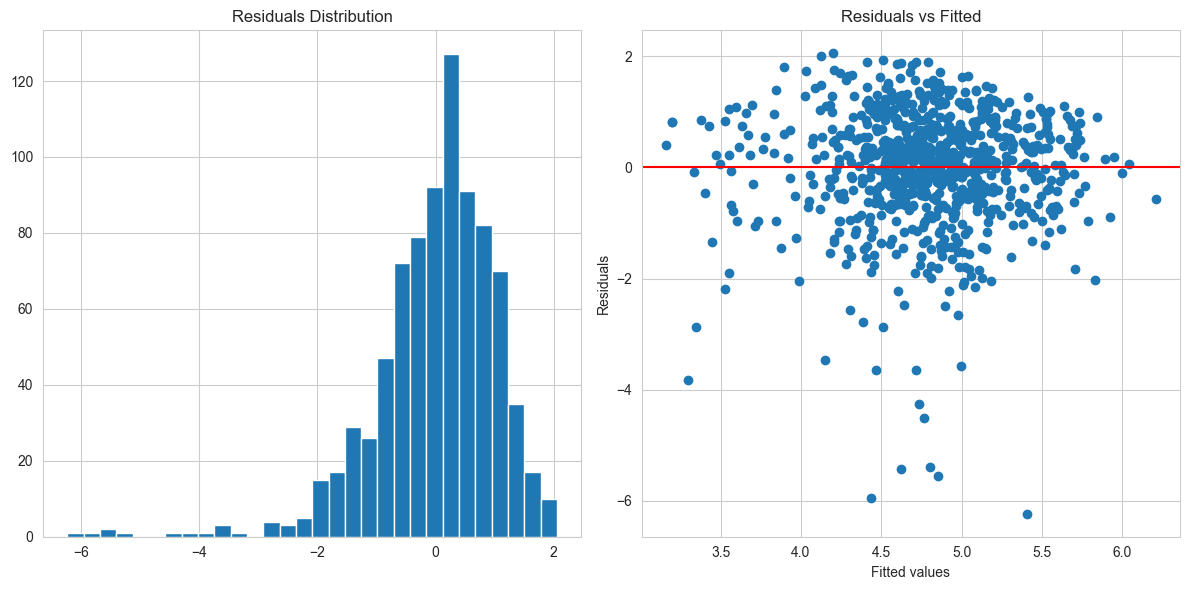

In [149]:
import pandas as pd
import numpy as np
import re
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Assuming df is already loaded
# First, let's recreate your original data preparation

# 1. Sanitize column names
bad = {'?': '_q', ' ': '_', '-': '_', '/': '_', '%': 'pct'}
df.rename(columns={c: re.sub('[^0-9A-Za-z_]', '',
                ''.join(bad.get(ch, ch) for ch in c))
                   for c in df.columns},
          inplace=True)

# 2. Build yield, trim outliers, log-transform
df = df[(df.landuseha > 0) & (df.cocoa_produce_kg > 0)].copy()
df["yield_ha"] = df.cocoa_produce_kg / df.landuseha
q1, q3 = df.yield_ha.quantile([.25, .75])
iqr = q3 - q1
df = df[(df.yield_ha <= q3 + 3*iqr) & (df.yield_ha >= max(0, q1 - 3*iqr))]
df["ln_yield"] = np.log(df.yield_ha)

# 3. Check for any problematic values after transformations
print("Check for infinities or NaNs in ln_yield:")
print(np.isinf(df.ln_yield).sum(), "infinities")
print(np.isnan(df.ln_yield).sum(), "NaNs")

# 4. Minimal list of raw columns that must be non-missing
raw_vars = [
    "ln_yield", "yrs_grow", "femhead",
    "herbicide_yn", "pesticide_yn", "fungicide_yn",
    "weeding_yn", "pruning_yn", "used_fert_q",
    "pest_loss", "disease_loss", "replant",
    "farm_rights",
    "cocoa_ages_0_5_weighted", "cocoa_ages_6_10_weighted",
    "cocoa_ages_11_19_weighted", "cocoa_ages_20_30_weighted",
    "econstatus", "vill", "district", "ethnicity", "hh_head_education"
]
df_reg = df.dropna(subset=raw_vars).copy()

# 5. Statistical analysis to diagnose issues

# Check correlation between predictors
numeric_vars = [
    "femhead", "herbicide_yn", "pesticide_yn", "fungicide_yn",
    "weeding_yn", "pruning_yn", "used_fert_q",
    "pest_loss", "disease_loss", "replant",
    "farm_rights",
    "cocoa_ages_0_5_weighted", "cocoa_ages_6_10_weighted",
    "cocoa_ages_11_19_weighted", "cocoa_ages_20_30_weighted",
    "econstatus"
]

print("\nChecking correlation matrix for numerical variables...")
correlation = df_reg[numeric_vars].corr()
print("Variables with correlation > 0.7:")
for i in range(len(numeric_vars)):
    for j in range(i+1, len(numeric_vars)):
        if abs(correlation.iloc[i, j]) > 0.7:
            print(f"{numeric_vars[i]} and {numeric_vars[j]}: {correlation.iloc[i, j]:.3f}")

# 6. Simplified models to identify issues

print("\nRunning simplified models to diagnose issues:")

# Model 1: Basic model without interactions, polynomials and fixed effects
formula1 = """
ln_yield ~ femhead + 
          herbicide_yn + pesticide_yn + fungicide_yn +
          weeding_yn + pruning_yn +
          used_fert_q +
          pest_loss + disease_loss + replant +
          farm_rights +
          cocoa_ages_0_5_weighted +
          cocoa_ages_6_10_weighted +
          cocoa_ages_11_19_weighted +
          cocoa_ages_20_30_weighted +
          econstatus
"""

print("\nModel 1: Basic model without interactions, polynomials and categorical variables")
try:
    fit1 = smf.ols(formula1, data=df_reg).fit(missing="drop")
    print("F-statistic:", fit1.fvalue)
    print("Prob(F-statistic):", fit1.f_pvalue)
except Exception as e:
    print("Error in Model 1:", e)

# Model 2: Add categorical variables
formula2 = """
ln_yield ~ C(yrs_grow) +
          femhead + 
          herbicide_yn + pesticide_yn + fungicide_yn +
          weeding_yn + pruning_yn +
          used_fert_q +
          pest_loss + disease_loss + replant +
          farm_rights +
          cocoa_ages_0_5_weighted +
          cocoa_ages_6_10_weighted +
          cocoa_ages_11_19_weighted +
          cocoa_ages_20_30_weighted +
          econstatus +
          C(ethnicity) +
          C(hh_head_education)
"""

print("\nModel 2: Adding categorical variables")
try:
    fit2 = smf.ols(formula2, data=df_reg).fit(missing="drop")
    print("F-statistic:", fit2.fvalue)
    print("Prob(F-statistic):", fit2.f_pvalue)
except Exception as e:
    print("Error in Model 2:", e)

# Model 3: Add polynomial and interaction terms
formula3 = """
ln_yield ~ C(yrs_grow) +
          femhead + 
          herbicide_yn + pesticide_yn + fungicide_yn +
          weeding_yn + pruning_yn +
          used_fert_q +
          used_fert_q:pesticide_yn +
          pest_loss + disease_loss + replant +
          farm_rights +
          cocoa_ages_0_5_weighted +
          cocoa_ages_6_10_weighted +
          cocoa_ages_11_19_weighted +
          cocoa_ages_20_30_weighted +
          econstatus + I(econstatus**2) +
          C(ethnicity) +
          C(hh_head_education)
"""

print("\nModel 3: Adding polynomial and interaction terms")
try:
    fit3 = smf.ols(formula3, data=df_reg).fit(missing="drop")
    print("F-statistic:", fit3.fvalue)
    print("Prob(F-statistic):", fit3.f_pvalue)
except Exception as e:
    print("Error in Model 3:", e)

# Model 4: Original model with different standard errors
formula4 = """
ln_yield ~ C(yrs_grow) +
          femhead +
          herbicide_yn + pesticide_yn + fungicide_yn +
          weeding_yn + pruning_yn +
          used_fert_q +
          used_fert_q:pesticide_yn +
          pest_loss + disease_loss + replant +
          farm_rights +
          cocoa_ages_0_5_weighted +
          cocoa_ages_6_10_weighted +
          cocoa_ages_11_19_weighted +
          cocoa_ages_20_30_weighted +
          econstatus + I(econstatus**2) +
          C(ethnicity) +
          C(hh_head_education) +
          hh_head_birthplace +
          screen_sharecrop
"""

print("\nModel 4: Original model with non-clustered standard errors")
try:
    fit4 = smf.ols(formula4, data=df_reg).fit(missing="drop")
    print("F-statistic:", fit4.fvalue)
    print("Prob(F-statistic):", fit4.f_pvalue)
except Exception as e:
    print("Error in Model 4:", e)

# Model 5: Original model with clustered standard errors (your original approach)
print("\nModel 5: Original model with clustered standard errors (your original approach)")
try:
    fit5 = smf.ols(formula4, data=df_reg).fit(
        cov_type="cluster",
        cov_kwds={"groups": df_reg["vill"]},
        missing="drop"
    )
    print("F-statistic:", fit5.fvalue)  # This might still be problematic
    print("Prob(F-statistic):", fit5.f_pvalue)
except Exception as e:
    print("Error in Model 5:", e)

# If Model 5 runs without errors, check for the number of clusters
if 'fit5' in locals():
    print("\nNumber of villages (clusters):", df_reg["vill"].nunique())
    print("Distribution of observations across clusters:")
    print(df_reg["vill"].value_counts())

# If any of the models ran successfully, examine multicollinearity
if 'fit1' in locals():
    # Create a dataframe for VIF calculation
    X = df_reg[numeric_vars].copy()
    
    # Calculate VIF for each feature
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    
    print("\nVariance Inflation Factors (VIF):")
    print(vif.sort_values("VIF", ascending=False))
    print("VIF > 10 indicates problematic multicollinearity")

# Print the best working model summary
best_model = None
if 'fit4' in locals():
    best_model = fit4
    print("\nUsing Model 4 (non-clustered SEs) for final results:")
elif 'fit3' in locals():
    best_model = fit3
    print("\nUsing Model 3 for final results:")
elif 'fit2' in locals():
    best_model = fit2
    print("\nUsing Model 2 for final results:")
elif 'fit1' in locals():
    best_model = fit1
    print("\nUsing Model 1 for final results:")

if best_model:
    print(best_model.summary())
    
    # Check residuals
    residuals = best_model.resid
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.hist(residuals, bins=30)
    plt.title('Residuals Distribution')
    
    plt.subplot(1, 2, 2)
    plt.scatter(best_model.fittedvalues, residuals)
    plt.axhline(y=0, color='r', linestyle='-')
    plt.title('Residuals vs Fitted')
    plt.xlabel('Fitted values')
    plt.ylabel('Residuals')
    
    plt.tight_layout()
    plt.savefig('residuals_plot.png')
    print("Residual plots saved to 'residuals_plot.png'")

Check for infinities or NaNs in ln_yield:
0 infinities
0 NaNs

Checking correlation matrix for numerical variables...
Variables with correlation > 0.7:

Running simplified models to diagnose issues:

Model 1: Basic model without interactions, polynomials and categorical variables
F-statistic: 3.8180138691086762
Prob(F-statistic): 2.9298139475431525e-28

Model 2: Adding categorical variables
F-statistic: 3.5245956819909177
Prob(F-statistic): 2.332287620497323e-27

Model 3: Adding polynomial and interaction terms
F-statistic: 3.5267032104164255
Prob(F-statistic): 1.2922989017874374e-27

Model 4: Original model with non-clustered standard errors
F-statistic: 3.4948739877013932
Prob(F-statistic): 1.958107664332348e-27

Model 5: Original model with clustered standard errors (your original approach)


c:\Users\Mohamad\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 139, but rank is 40
  warnings.warn('covariance of constraints does not have full '


F-statistic: 23.459203810480552
Prob(F-statistic): 1.9083789327418505e-35

Number of villages (clusters): 100
Distribution of observations across clusters:
vill
71007    15
74002    15
71009    15
73003    15
71008    15
         ..
41023     2
52001     2
41024     2
51004     2
53001     1
Name: count, Length: 100, dtype: int64

Variance Inflation Factors (VIF):
                     Variable       VIF
10                farm_rights  8.978376
7                   pest_loss  6.282384
15                 econstatus  6.183772
8                disease_loss  3.859271
2                pesticide_yn  3.369105
4                  weeding_yn  3.210282
13  cocoa_ages_11_19_weighted  2.791465
14  cocoa_ages_20_30_weighted  2.626925
12   cocoa_ages_6_10_weighted  2.542880
5                  pruning_yn  2.238340
11    cocoa_ages_0_5_weighted  2.047849
1                herbicide_yn  1.896190
9                     replant  1.764458
3                fungicide_yn  1.703685
6                 used_fert_q  1.

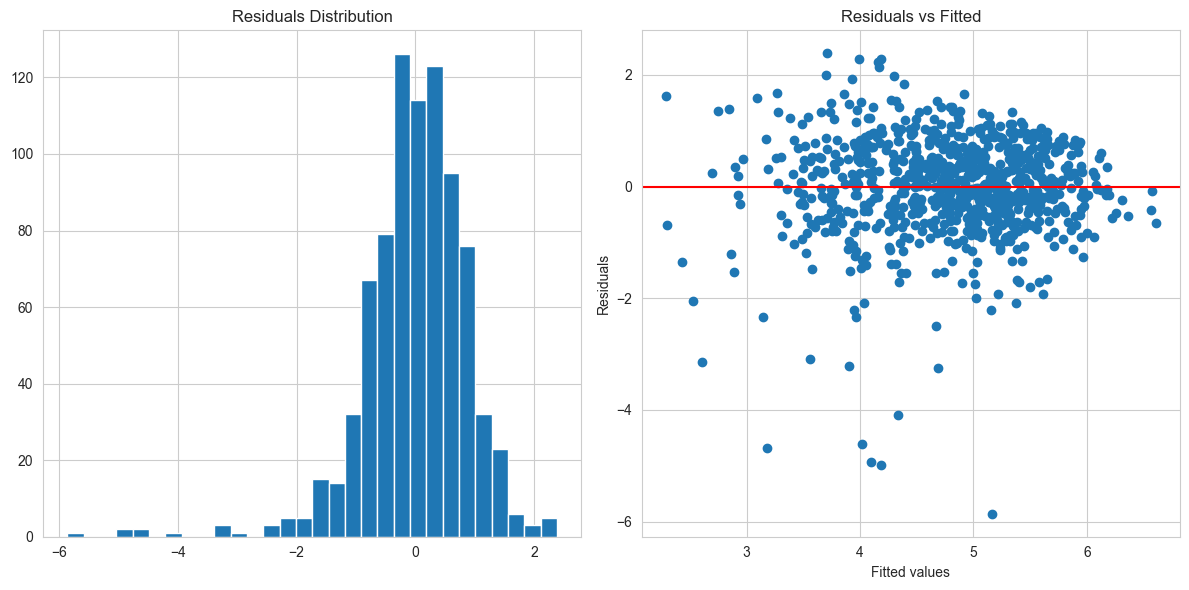

In [150]:
import pandas as pd
import numpy as np
import re
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Assuming df is already loaded
# First, let's recreate your original data preparation

# 1. Sanitize column names
bad = {'?': '_q', ' ': '_', '-': '_', '/': '_', '%': 'pct'}
df.rename(columns={c: re.sub('[^0-9A-Za-z_]', '',
                ''.join(bad.get(ch, ch) for ch in c))
                   for c in df.columns},
          inplace=True)

# 2. Build yield, trim outliers, log-transform
df = df[(df.landuseha > 0) & (df.cocoa_produce_kg > 0)].copy()
df["yield_ha"] = df.cocoa_produce_kg / df.landuseha
q1, q3 = df.yield_ha.quantile([.25, .75])
iqr = q3 - q1
df = df[(df.yield_ha <= q3 + 3*iqr) & (df.yield_ha >= max(0, q1 - 3*iqr))]
df["ln_yield"] = np.log(df.yield_ha)

# 3. Check for any problematic values after transformations
print("Check for infinities or NaNs in ln_yield:")
print(np.isinf(df.ln_yield).sum(), "infinities")
print(np.isnan(df.ln_yield).sum(), "NaNs")

# 4. Minimal list of raw columns that must be non-missing
raw_vars = [
    "ln_yield", "yrs_grow", "femhead",
    "herbicide_yn", "pesticide_yn", "fungicide_yn",
    "weeding_yn", "pruning_yn", "used_fert_q",
    "pest_loss", "disease_loss", "replant",
    "farm_rights",
    "cocoa_ages_0_5_weighted", "cocoa_ages_6_10_weighted",
    "cocoa_ages_11_19_weighted", "cocoa_ages_20_30_weighted",
    "econstatus", "vill", "district", "ethnicity", "hh_head_education"
]
df_reg = df.dropna(subset=raw_vars).copy()

# 5. Statistical analysis to diagnose issues

# Check correlation between predictors
numeric_vars = [
    "femhead", "herbicide_yn", "pesticide_yn", "fungicide_yn",
    "weeding_yn", "pruning_yn", "used_fert_q",
    "pest_loss", "disease_loss", "replant",
    "farm_rights",
    "cocoa_ages_0_5_weighted", "cocoa_ages_6_10_weighted",
    "cocoa_ages_11_19_weighted", "cocoa_ages_20_30_weighted",
    "econstatus" 
]

print("\nChecking correlation matrix for numerical variables...")
correlation = df_reg[numeric_vars].corr()
print("Variables with correlation > 0.7:")
for i in range(len(numeric_vars)):
    for j in range(i+1, len(numeric_vars)):
        if abs(correlation.iloc[i, j]) > 0.7:
            print(f"{numeric_vars[i]} and {numeric_vars[j]}: {correlation.iloc[i, j]:.3f}")

# 6. Simplified models to identify issues

print("\nRunning simplified models to diagnose issues:")

# Model 1: Basic model without interactions, polynomials and fixed effects
formula1 = """
ln_yield ~ femhead + 
          herbicide_yn + pesticide_yn + fungicide_yn +
          weeding_yn + pruning_yn +
          used_fert_q +
          pest_loss + disease_loss + replant +
          farm_rights +
          cocoa_ages_0_5_weighted +
          cocoa_ages_6_10_weighted +
          cocoa_ages_11_19_weighted +
          cocoa_ages_20_30_weighted +
          econstatus +
          C(vill)
"""

print("\nModel 1: Basic model without interactions, polynomials and categorical variables")
try:
    fit1 = smf.ols(formula1, data=df_reg).fit(missing="drop")
    print("F-statistic:", fit1.fvalue)
    print("Prob(F-statistic):", fit1.f_pvalue)
except Exception as e:
    print("Error in Model 1:", e)

# Model 2: Add categorical variables
formula2 = """
ln_yield ~ C(yrs_grow) +
          femhead + 
          herbicide_yn + pesticide_yn + fungicide_yn +
          weeding_yn + pruning_yn +
          used_fert_q +
          pest_loss + disease_loss + replant +
          farm_rights +
          cocoa_ages_0_5_weighted +
          cocoa_ages_6_10_weighted +
          cocoa_ages_11_19_weighted +
          cocoa_ages_20_30_weighted +
          econstatus +
          C(ethnicity) +
          C(hh_head_education) +
          C(vill)

"""

print("\nModel 2: Adding categorical variables")
try:
    fit2 = smf.ols(formula2, data=df_reg).fit(missing="drop")
    print("F-statistic:", fit2.fvalue)
    print("Prob(F-statistic):", fit2.f_pvalue)
except Exception as e:
    print("Error in Model 2:", e)

# Model 3: Add polynomial and interaction terms
formula3 = """
ln_yield ~ C(yrs_grow) +
          femhead + 
          herbicide_yn + pesticide_yn + fungicide_yn +
          weeding_yn + pruning_yn +
          used_fert_q +
          used_fert_q:pesticide_yn +
          pest_loss + disease_loss + replant +
          farm_rights +
          cocoa_ages_0_5_weighted +
          cocoa_ages_6_10_weighted +
          cocoa_ages_11_19_weighted +
          cocoa_ages_20_30_weighted +
          econstatus + I(econstatus**2) +
          C(ethnicity) +
          C(hh_head_education) +
          C(vill)
"""

print("\nModel 3: Adding polynomial and interaction terms")
try:
    fit3 = smf.ols(formula3, data=df_reg).fit(missing="drop")
    print("F-statistic:", fit3.fvalue)
    print("Prob(F-statistic):", fit3.f_pvalue)
except Exception as e:
    print("Error in Model 3:", e)

# Model 4: Original model with different standard errors
formula4 = """
ln_yield ~ C(yrs_grow) +
          femhead +
          herbicide_yn + pesticide_yn + fungicide_yn +
          weeding_yn + pruning_yn +
          used_fert_q +
          used_fert_q:pesticide_yn +
          pest_loss + disease_loss + replant +
          farm_rights +
          cocoa_ages_0_5_weighted +
          cocoa_ages_6_10_weighted +
          cocoa_ages_11_19_weighted +
          cocoa_ages_20_30_weighted +
          econstatus + I(econstatus**2) +
          C(ethnicity) +
          C(hh_head_education) +
          hh_head_birthplace +
          screen_sharecrop +
          C(vill)
"""

print("\nModel 4: Original model with non-clustered standard errors")
try:
    fit4 = smf.ols(formula4, data=df_reg).fit(missing="drop")
    print("F-statistic:", fit4.fvalue)
    print("Prob(F-statistic):", fit4.f_pvalue)
except Exception as e:
    print("Error in Model 4:", e)

# Model 5: Original model with clustered standard errors (your original approach)
print("\nModel 5: Original model with clustered standard errors (your original approach)")
try:
    fit5 = smf.ols(formula4, data=df_reg).fit(
        cov_type="cluster",
        cov_kwds={"groups": df_reg["vill"]},
        missing="drop"
    )
    print("F-statistic:", fit5.fvalue)  # This might still be problematic
    print("Prob(F-statistic):", fit5.f_pvalue)
except Exception as e:
    print("Error in Model 5:", e)

# If Model 5 runs without errors, check for the number of clusters
if 'fit5' in locals():
    print("\nNumber of villages (clusters):", df_reg["vill"].nunique())
    print("Distribution of observations across clusters:")
    print(df_reg["vill"].value_counts())

# If any of the models ran successfully, examine multicollinearity
if 'fit1' in locals():
    # Create a dataframe for VIF calculation
    X = df_reg[numeric_vars].copy()
    
    # Calculate VIF for each feature
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    
    print("\nVariance Inflation Factors (VIF):")
    print(vif.sort_values("VIF", ascending=False))
    print("VIF > 10 indicates problematic multicollinearity")

# Print the best working model summary
best_model = None
if 'fit4' in locals():
    best_model = fit4
    print("\nUsing Model 4 (non-clustered SEs) for final results:")
elif 'fit3' in locals():
    best_model = fit3
    print("\nUsing Model 3 for final results:")
elif 'fit2' in locals():
    best_model = fit2
    print("\nUsing Model 2 for final results:")
elif 'fit1' in locals():
    best_model = fit1
    print("\nUsing Model 1 for final results:")

if best_model:
    print(best_model.summary())
    
    # Check residuals
    residuals = best_model.resid
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.hist(residuals, bins=30)
    plt.title('Residuals Distribution')
    
    plt.subplot(1, 2, 2)
    plt.scatter(best_model.fittedvalues, residuals)
    plt.axhline(y=0, color='r', linestyle='-')
    plt.title('Residuals vs Fitted')
    plt.xlabel('Fitted values')
    plt.ylabel('Residuals')
    
    plt.tight_layout()
    plt.savefig('residuals_plot.png')
    print("Residual plots saved to 'residuals_plot.png'")

In [151]:
# Print unique values in 'village' column
print("\nUnique villages:")
print(df['village'].unique())

print("\nTotal number of unique villages:", len(df['village'].unique()))


Unique villages:
['Koitienko' 'KLODIO' 'Ananguié' 'BOHOUIN' 'BEOUE' 'BOGUIé' 'Akoikro'
 "N'Djorekro" 'ASSE ORIé' 'Affery' 'DONIE' 'Agbaou' 'Tioumoukro' 'GBAROU'
 'Kouassi-Béniékro' 'Bossematié' 'Anuanua' 'Améakro' 'SEH' 'TATE1'
 'Yakassé-Mé' 'Affalikro' 'NIGRE' 'Biasso' 'Kokonou'
 'Adjoumani-Kouassikro' 'Montézo' 'Amian-Kouassikro' "N'Gouanda" 'Takima'
 'Alakro' 'Nyan' 'KARIE' 'Bébou' 'MOBIOKOUA' 'TAOULOKE' 'Annépé'
 'Bécédi-Brignan' 'IRATO' 'Abongoua' 'FETE' 'Kouadiokro' 'MAHINO2' 'TATE2'
 'Ahéoua' 'DAHIOKE' 'Kabrankro' 'MERE' 'Bassadzin' 'PARA' 'Adiaoukoi'
 "N'DRIKRO" 'Kouadioukro' 'Monin' 'Dramanekro' 'GRABO' 'POUTOU'
 'TEPOIBOKE' 'MAMINI' 'NIRO' 'Anougbakro' 'Adahou' 'GNATO' 'DEBLABLAI'
 'Assakro' 'Ahininkro' 'Ahuasso' 'Akacomoékro' 'Amélékia' 'Anékouadiokro'
 'Appoisso' 'Assémanou' 'Bokakokoré' 'Borobo' 'Dallo' 'DEWAKE'
 'Ebilassokro' 'Elinso' 'GBAPET' 'GBELETO' "N'Grakon" 'Niablé' 'OLODIO'
 'PETIEGRABO' 'Satikran' 'SOTO' 'Soukoussoukou' 'Tahakro' 'YOUKOU'
 'Zébénou' 'Manfia' 'DJ

In [152]:
import pandas as pd
import json

# 1) Read in your cleaned household DataFrame
df = pd.read_csv("C:/Users/Mohamad/Documents/GitHub/GAFL_RESTORE_MKM/Data/processed/CDI_HOUSEHOLD_UNEDITTED.csv")

# build dict: vill ID (int or str) → village name
vill_to_name = df.set_index("vill")["village"].to_dict()
# inspect first entries
list(vill_to_name.items())[:120
                           ]


[(51024, 'Koitienko'),
 (41011, 'KLODIO'),
 (51028, 'Ananguié'),
 (74003, 'BOHOUIN'),
 (41017, 'BEOUE'),
 (51030, 'Assémanou'),
 (72003, 'BOGUIé'),
 (51002, 'Akoikro'),
 (53004, "N'Djorekro"),
 (75001, 'ASSE ORIé'),
 (41008, 'DAHIOKE'),
 (73003, 'Affery'),
 (41009, 'DONIE'),
 (73004, 'Agbaou'),
 (62001, 'Tioumoukro'),
 (41003, 'GBAROU'),
 (51018, 'Kouassi-Béniékro'),
 (51047, 'Bossematié'),
 (51003, 'Anuanua'),
 (51020, 'Améakro'),
 (41014, 'SEH'),
 (41016, 'TATE1'),
 (71009, 'Yakassé-Mé'),
 (51009, 'Affalikro'),
 (41021, 'NIGRE'),
 (71005, 'Biasso'),
 (53001, 'Kokonou'),
 (51008, 'Adjoumani-Kouassikro'),
 (74002, 'Montézo'),
 (51054, 'Amian-Kouassikro'),
 (51011, "N'Gouanda"),
 (51005, 'Takima'),
 (64001, 'Alakro'),
 (51036, 'Ahuasso'),
 (71006, 'Nyan'),
 (41019, 'KARIE'),
 (51015, 'Bébou'),
 (72005, 'MOBIOKOUA'),
 (51029, 'Assakro'),
 (41015, 'TAOULOKE'),
 (71001, 'Annépé'),
 (54002, 'Bécédi-Brignan'),
 (41037, 'IRATO'),
 (61001, 'Abongoua'),
 (41004, 'FETE'),
 (51025, 'Kouadiokro'),

In [162]:
# 1) Build the ISO lookup DataFrame (once)
iso_df = pd.DataFrame({
    'region': [4,5,6,7],
    'iso_region': ['CIBS','CICM','CILC','CILG']
})

# 2) Build the regression residuals DataFrame (once)
region_residuals_df = pd.DataFrame(records) \
    .sort_values('mean_residual') \
    .rename(columns={'mean_residual':'mean_residual'})

# 3) Merge ISO + residuals into a fresh plot_df
region_df = (
    iso_df
      .merge(region_residuals_df, on='region', how='left')
)
print(region_df.to_string(index=False))




 region iso_region  mean_residual  num_villages_defined  villages_in_sample
      4       CIBS       0.249492                    32                  32
      5       CICM       0.051797                    43                  43
      6       CILC      -0.649513                     4                   4
      7       CILG      -0.106683                    23                  23


In [160]:
# Step 2: build region → [vill IDs] mapping

# 1) Pull only the two columns and drop any exact duplicates
region_df = df[['region', 'vill']].drop_duplicates()

# 2) Group by region and aggregate the list of vill IDs
region_to_vills = (
    region_df
      .groupby('region')['vill']
      .apply(list)
      .to_dict()
)

# 3) Inspect
for reg, vills in region_to_vills.items():
    print(f"Region {reg!r} has {len(vills)} villages:", vills[:5], "…")


Region 4 has 32 villages: [41011, 41017, 41008, 41009, 41003] …
Region 5 has 43 villages: [51024, 51028, 51030, 51002, 53004] …
Region 6 has 4 villages: [62001, 64001, 61001, 64002] …
Region 7 has 23 villages: [74003, 72003, 75001, 73003, 73004] …


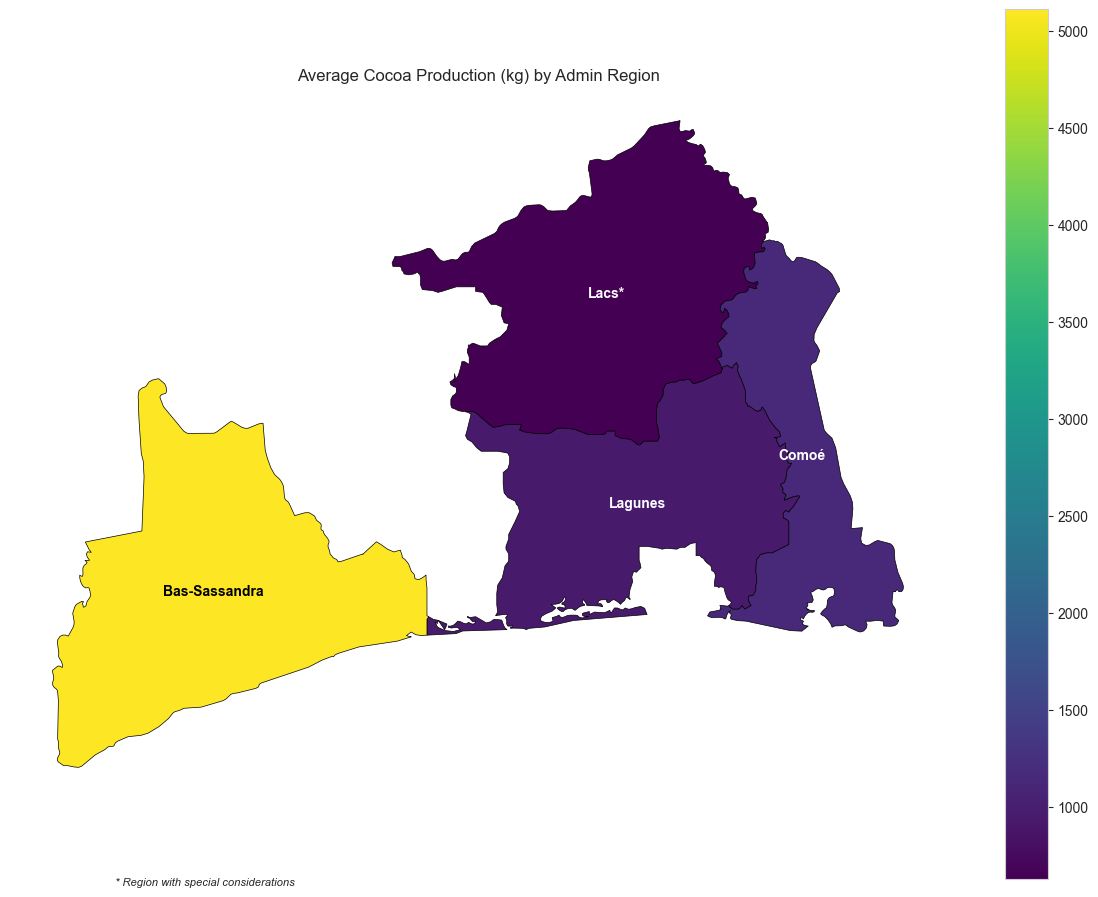

In [163]:
import geopandas as gpd
from matplotlib.colors import Normalize, rgb2hex, to_rgb
import matplotlib.cm as cm

# Calculate average cocoa production per household by region
region_output = (
    df.groupby('region')['cocoa_produce_kg']
    .mean()
    .reset_index(name='avg_cocoa_kg')
)

# Map survey region codes to ISO codes
region_output['iso_region'] = region_output['region'].map(region_code_to_iso)

# Load the GeoJSON file
gdf = gpd.read_file("C:/Users/Mohamad/Documents/GitHub/GAFL_RESTORE_MKM/ci.json")

# Merge with region_output
merged_cocoa = gdf.merge(region_output, left_on='id', right_on='iso_region', how='left')

# Filter to only include regions with data (non-null avg_cocoa_kg)
filtered_merged_cocoa = merged_cocoa[merged_cocoa['avg_cocoa_kg'].notna()]

# Create a custom colormap
cmap = plt.cm.viridis  # Use viridis or any other colormap you prefer
norm = Normalize(vmin=filtered_merged_cocoa['avg_cocoa_kg'].min(), 
                 vmax=filtered_merged_cocoa['avg_cocoa_kg'].max())

# Plot the choropleth
fig, ax = plt.subplots(figsize=(12, 9))
filtered_merged_cocoa.plot(
    column='avg_cocoa_kg',
    cmap=cmap,
    legend=True,
    linewidth=0.5,
    edgecolor='black',
    ax=ax
)

# Function to determine text color based on background brightness
def get_text_color(bg_color):
    r, g, b = to_rgb(bg_color)
    brightness = (r * 299 + g * 587 + b * 114) / 1000
    return 'white' if brightness < 0.5 else 'black'

# Add region names at centroids with adaptive text color
for idx, row in filtered_merged_cocoa.iterrows():
    # Get the color for this region's value
    color_value = norm(row['avg_cocoa_kg'])
    bg_color = rgb2hex(cmap(color_value))
    
    # Determine text color based on background brightness
    text_color = get_text_color(bg_color)
    
    label = row['name'] + '*' if row['name'] == 'Lacs' else row['name']
    ax.text(
        row.geometry.centroid.x,
        row.geometry.centroid.y,
        label,
        fontsize=10,
        fontweight='bold',
        ha='center',
        va='center',
        color=text_color  # Use adaptive text color
    )

ax.set_title("Average Cocoa Production (kg) by Admin Region")
ax.axis('off')

# Add a note for the asterisk
plt.figtext(0.1, 0.01, "* Region with special considerations", fontsize=8, style='italic')

plt.tight_layout()
plt.show()

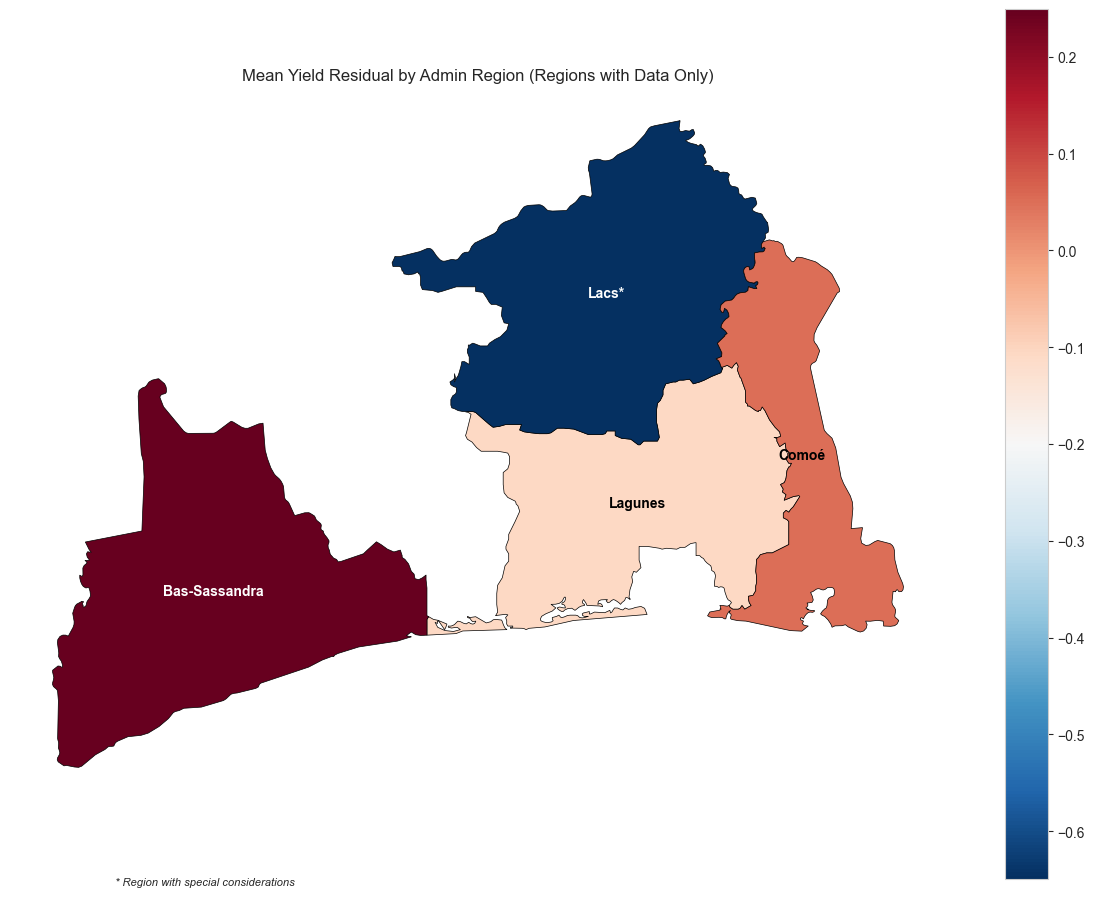

In [164]:


# Load the GeoJSON file
gdf = gpd.read_file("C:/Users/Mohamad/Documents/GitHub/GAFL_RESTORE_MKM/ci.json")

# Merge with region_df
merged = gdf.merge(region_df, left_on='id', right_on='iso_region', how='left')

# Filter to only include regions with data (non-null mean_residual)
filtered_merged = merged[merged['mean_residual'].notna()]

# Create a custom colormap - using a diverging colormap since residuals can be positive or negative
cmap = plt.cm.RdBu_r  # Red-Blue diverging colormap (reversed)
norm = Normalize(
    vmin=filtered_merged['mean_residual'].min(), 
    vmax=filtered_merged['mean_residual'].max()
)

# Plot the choropleth
fig, ax = plt.subplots(figsize=(12, 9))
filtered_merged.plot(
    column='mean_residual',
    cmap=cmap,
    legend=True,
    linewidth=0.5,
    edgecolor='black',
    ax=ax
)

# Function to determine text color based on background brightness
def get_text_color(bg_color):
    r, g, b = to_rgb(bg_color)
    brightness = (r * 299 + g * 587 + b * 114) / 1000
    return 'white' if brightness < 0.5 else 'black'

# Add region names at centroids with adaptive text color
for idx, row in filtered_merged.iterrows():  # Fixed: using filtered_merged instead of filtered_merged_cocoa
    # Get the color for this region's value
    color_value = norm(row['mean_residual'])
    bg_color = rgb2hex(cmap(color_value))
    
    # Determine text color based on background brightness
    text_color = get_text_color(bg_color)
    
    label = row['name'] + '*' if row['name'] == 'Lacs' else row['name']
    ax.text(
        row.geometry.centroid.x,
        row.geometry.centroid.y,
        label,
        fontsize=10,
        fontweight='bold',
        ha='center',
        va='center',
        color=text_color  # Use adaptive text color
    )

ax.set_title("Mean Yield Residual by Admin Region (Regions with Data Only)")
ax.axis('off')

# Add a note for the asterisk
plt.figtext(0.1, 0.01, "* Region with special considerations", fontsize=8, style='italic')

plt.tight_layout()
plt.show()